# Coffee flavor map — FastText (Phase 1)

We turn coffee tasting text into **vectors** (with **subword** n-grams, Bojanowski et al.).  (numbers) for each word. Words that appear in similar contexts get **similar vectors**. Then we check neighbors, a small **analogy**, a **similarity table** for flavor words, and a **2D plot**.

In [1]:
# Install Word2Vec library in *this* notebook kernel (no-op if already there)
%pip install -q "gensim>=4.3.0"

import os
import re
import subprocess
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import FastText
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Note: you may need to restart the kernel to use updated packages.


## Google Colab

If you only uploaded this notebook, **`corpus.txt` is missing**. The next cell clones the repo into `/content/ml-nlp-guide` and moves into the project folder. On your own computer, this cell does nothing.

In [2]:
if Path("/content").is_dir() and not os.environ.get("COFFEE_FLAVOR_MAP_ROOT"):
    _clone = Path("/content/ml-nlp-guide")
    _url = "https://github.com/YOUSEF-ysfxjo/ml-nlp-guide.git"
    _corpus = _clone / "coffee-flavor-map" / "data" / "processed" / "corpus.txt"
    if not _corpus.is_file():
        if not _clone.is_dir():
            subprocess.run(
                ["git", "clone", "--depth", "1", _url, str(_clone)],
                check=True,
                cwd="/content",
            )
        if not _corpus.is_file():
            raise FileNotFoundError(
                f"Expected corpus at {_corpus} after clone. Set COFFEE_FLAVOR_MAP_ROOT if using Drive."
            )
    os.chdir(_clone / "coffee-flavor-map" / "phase1_global")
    print("Colab OK:", Path.cwd())

## Find `corpus.txt`

We need the cleaned text file: **`coffee-flavor-map/data/processed/corpus.txt`**. The code searches from the current folder upward, and on Colab also searches under `/content`. You can override with `COFFEE_FLAVOR_MAP_ROOT`.

In [3]:
_REL_IN_ROOT = Path("data") / "processed" / "corpus.txt"
_REL_IN_PARENT = Path("coffee-flavor-map") / "data" / "processed" / "corpus.txt"


def _colab_bfs_bases(max_depth=5, max_nodes=400):
    """Search under /content (Colab) so nested clones are found."""
    bases = []
    content = Path("/content")
    if not content.is_dir():
        return bases
    seen = set()
    q = deque([(content.resolve(), 0)])
    while q and len(seen) < max_nodes:
        path, depth = q.popleft()
        if path in seen:
            continue
        seen.add(path)
        bases.append(path)
        if depth >= max_depth:
            continue
        try:
            for ch in sorted(path.iterdir()):
                if ch.is_dir() and not ch.name.startswith("."):
                    q.append((ch.resolve(), depth + 1))
        except (OSError, PermissionError):
            pass
    return bases


def _find_corpus_txt():
    env_root = os.environ.get("COFFEE_FLAVOR_MAP_ROOT")
    if env_root:
        root = Path(env_root).expanduser().resolve()
        p = root / _REL_IN_ROOT
        if p.is_file():
            return root, p
    start = Path.cwd().resolve()
    tried = []
    seen_bases = set()
    bases = []
    for b in _colab_bfs_bases() + [start, *start.parents]:
        r = b.resolve()
        if r in seen_bases:
            continue
        seen_bases.add(r)
        bases.append(r)
    for base in bases:
        for rel in (_REL_IN_ROOT, _REL_IN_PARENT):
            p = (base / rel).resolve()
            tried.append(p)
            if p.is_file():
                return p.parent.parent.parent, p
    msg = "corpus.txt not found. Sample paths:\n" + "\n".join(f"  {x}" for x in tried[:40])
    raise FileNotFoundError(msg)


PROJECT_ROOT, file_path = _find_corpus_txt()
MODEL_PATH = PROJECT_ROOT / "phase1_global" / "fasttext.model"
print(f"PROJECT_ROOT = {PROJECT_ROOT}\nfile_path     = {file_path}")

PROJECT_ROOT = /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map
file_path     = /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map/data/processed/corpus.txt


## Load the corpus

Each **line** becomes one sentence (list of tokens). We lowercase, drop punctuation, and keep tokens with length ≥ 2.

In [4]:
def preprocess_line(line):
    line = line.strip().lower()
    line = re.sub(r"[^\w\s-]", " ", line)  # keep letters, digits, _, hyphen
    tokens = line.split()
    return [t for t in tokens if len(t) >= 2]


corpus = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        tokens = preprocess_line(line)
        if tokens:
            corpus.append(tokens)

print(f"Loaded {len(corpus)} sentences. First 3: {corpus[:3]}")

Loaded 5092 sentences. First 3: [['crisply', 'sweet', 'cocoa-toned'], ['lemon', 'blossom', 'roasted', 'cacao', 'nib', 'date', 'rice', 'candy', 'white', 'peppercorn', 'in', 'aroma', 'and', 'cup'], ['savory-tart', 'structure', 'delicate', 'silky', 'mouthfeel']]


## Train FastText and save

Same hyperparameters as Word2Vec where possible: **skip-gram** (`sg=1`), **`vector_size`**, **`window`**, **`min_count`**, **`epochs`**. FastText adds **character n-grams** (`min_n`, `max_n`) so rare words and variants share structure.

- **`vector_size`**: length of each word vector  
- **`window`**: how far left/right the model looks  
- **`min_count`**: ignore very rare words  
- **`sg=1`**: skip-gram (good for rarer words in a small corpus)  

The model file is written next to this notebook under `phase1_global/`.

In [5]:
VECTOR_SIZE = 100
WINDOW = 5
MIN_COUNT = 10
WORKERS = 4
SG = 1  # 1 = skip-gram, 0 = CBOW

model = FastText(
    sentences=corpus,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=SG,
    epochs=5,  # multiple passes over sentences (stable vs single pass)
    min_n=3,
    max_n=6,  # character n-gram range (FastText default-style)
)
model.save(str(MODEL_PATH))
print(f"Saved {MODEL_PATH} | vocab={len(model.wv):,}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Saved /Users/yousef/Desktop/projects/ml-nlp-guide/coffee-flavor-map/phase1_global/fasttext.model | vocab=359


## Nearest words and one analogy

Neighbors use the **full** FastText word vector (word + subwords; **gensim** `wv.most_similar` uses the word as a whole token when in vocabulary).

**`most_similar`** = words whose vectors are closest (cosine similarity).  
**Analogy** `positive=[A,B], negative=[C]` ≈ vector **A − C + B**; here we use *berry + chocolate − lemon* as a demo (results depend on your text).

In [6]:
for flavor in ("lemon", "chocolate", "vanilla"):
    try:
        print(f"\nMost similar to '{flavor}':")
        for w, s in model.wv.most_similar(flavor, topn=5):
            print(f"  {w}: {s:.4f}")
    except KeyError:
        print(f"'{flavor}' not in vocabulary")

try:
    print("\nAnalogy: berry + chocolate - lemon ≈")
    for w, s in model.wv.most_similar(positive=["berry", "chocolate"], negative=["lemon"], topn=5):
        print(f"  {w}: {s:.4f}")
except KeyError as e:
    print("Analogy skipped:", e)


Most similar to 'lemon':
  star: 0.9905
  jasmine: 0.9862
  lilac: 0.9815
  tangerine: 0.9804
  nectarine: 0.9795

Most similar to 'chocolate':
  spices: 0.9375
  nut: 0.9217
  passionfruit: 0.9119
  aged: 0.9093
  date: 0.9086

Most similar to 'vanilla':
  pomelo: 0.9983
  pomegranate: 0.9982
  lychee: 0.9978
  clove: 0.9977
  guava: 0.9974

Analogy: berry + chocolate - lemon ≈
  support: 0.8955
  supported: 0.8933
  spice: 0.8840
  tones: 0.8732
  chocolate-toned: 0.8653


## Flavor-word similarity matrix

We pick a **small list** of flavor words (from a wheel-style list). Words not in the vocabulary are skipped. The table shows **cosine similarity** between each pair (1 = same direction, 0 = unrelated).

In [7]:
target_flavors = [
    "lemon", "chocolate", "cocoa", "floral", "nutty",
    "citrus", "berry", "honey", "vanilla", "fruity",
    "caramel", "roasted", "jasmine", "acidic",
]
existing_flavors = [w for w in target_flavors if w in model.wv]
missing = set(target_flavors) - set(existing_flavors)
print(f"Flavor terms in vocab: {len(existing_flavors)} | dropped: {missing or 'none'}")

sim = [[model.wv.similarity(a, b) for b in existing_flavors] for a in existing_flavors]
df_sim = pd.DataFrame(sim, index=existing_flavors, columns=existing_flavors)
display(df_sim.round(3))

print("\nTop neighbor within flavor list:")
for target in existing_flavors:
    others = [w for w in existing_flavors if w != target]
    top = max(others, key=lambda x: model.wv.similarity(target, x))
    sc = model.wv.similarity(target, top)
    print(f"  {target:<10} -> {top:<10} ({sc:.3f})")

Flavor terms in vocab: 14 | dropped: none


,lemon,chocolate,cocoa,floral,nutty,citrus,berry,honey,vanilla,fruity,caramel,roasted,jasmine,acidic
lemon,1.000,0.774,0.974,0.234,0.547,0.674,0.857,0.971,0.965,0.189,0.960,0.936,0.986,0.234
chocolate,0.774,1.000,0.792,0.522,0.661,0.692,0.861,0.829,0.891,0.358,0.903,0.757,0.827,0.243
cocoa,0.974,0.792,1.000,0.306,0.593,0.731,0.893,0.972,0.946,0.243,0.953,0.880,0.977,0.222
floral,0.234,0.522,0.306,1.000,0.902,0.799,0.585,0.271,0.357,0.931,0.372,0.159,0.298,0.675
nutty,0.547,0.661,0.593,0.902,1.000,0.957,0.793,0.581,0.635,0.895,0.644,0.447,0.583,0.772
citrus,0.674,0.692,0.731,0.799,0.957,1.000,0.899,0.693,0.719,0.755,0.744,0.520,0.704,0.616
berry,0.857,0.861,0.893,0.585,0.793,0.899,1.000,0.866,0.889,0.460,0.915,0.719,0.882,0.323
honey,0.971,0.829,0.972,0.271,0.581,0.693,0.866,1.000,0.978,0.230,0.975,0.925,0.978,0.274
vanilla,0.965,0.891,0.946,0.357,0.635,0.719,0.889,0.978,1.000,0.287,0.994,0.939,0.979,0.311
fruity,0.189,0.358,0.243,0.931,0.895,0.755,0.460,0.230,0.287,1.000,0.279,0.140,0.224,0.876



Top neighbor within flavor list:
  lemon      -> jasmine    (0.986)
  chocolate  -> caramel    (0.903)
  cocoa      -> jasmine    (0.977)
  floral     -> fruity     (0.931)
  nutty      -> citrus     (0.957)
  citrus     -> nutty      (0.957)
  berry      -> caramel    (0.915)
  honey      -> vanilla    (0.978)
  vanilla    -> caramel    (0.994)
  fruity     -> floral     (0.931)
  caramel    -> vanilla    (0.994)
  roasted    -> vanilla    (0.939)
  jasmine    -> lemon      (0.986)
  acidic     -> fruity     (0.876)


## 2D plot (PCA + KMeans)

**PCA** squeezes the 100-dimensional vectors down to **2** for drawing. **KMeans** groups words into a few clusters (colors) using the *full* vectors. Nearby points are more similar in the original space (roughly).

PCA explained variance ratio: [0.7476905  0.13509592]
Clusters: [('lemon', np.int32(3)), ('chocolate', np.int32(0)), ('cocoa', np.int32(3)), ('floral', np.int32(2)), ('nutty', np.int32(1)), ('citrus', np.int32(1)), ('berry', np.int32(0)), ('honey', np.int32(3)), ('vanilla', np.int32(0)), ('fruity', np.int32(2)), ('caramel', np.int32(0)), ('roasted', np.int32(3)), ('jasmine', np.int32(3)), ('acidic', np.int32(2))]


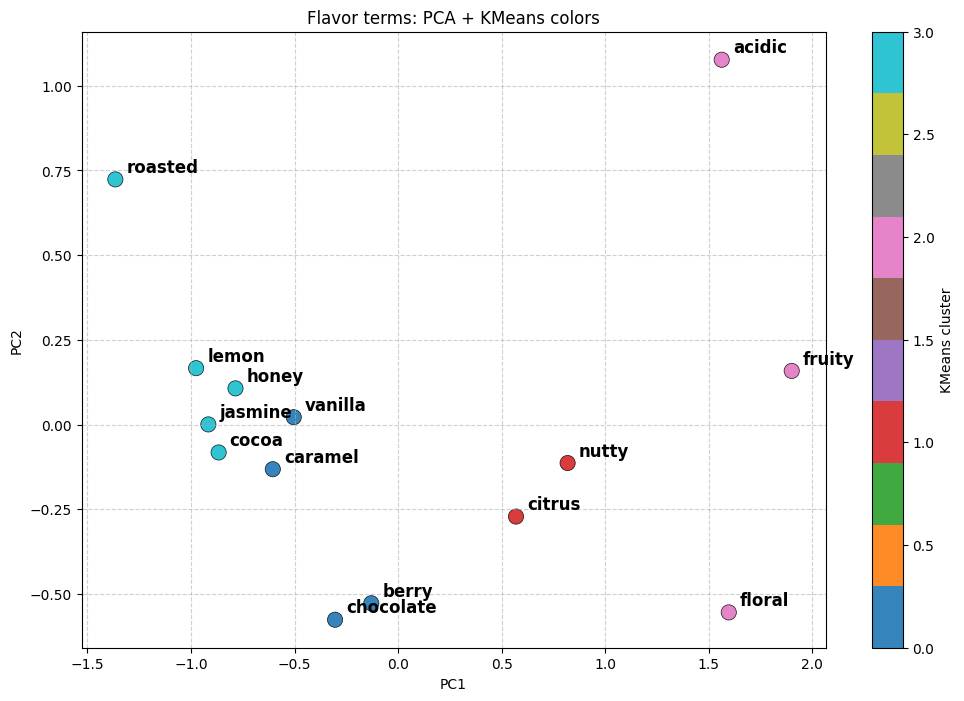

In [8]:
terms_in_vocab = existing_flavors
vectors = np.array([model.wv[t] for t in terms_in_vocab])

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(vectors)

n_clusters = min(4, max(2, len(terms_in_vocab) // 3))
cluster_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(vectors)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Clusters:", list(zip(terms_in_vocab, cluster_labels)))

plt.figure(figsize=(12, 8))
sc = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=cluster_labels, cmap="tab10", s=120,
    edgecolors="black", linewidths=0.5, alpha=0.9,
)
plt.colorbar(sc, label="KMeans cluster")
for i, word in enumerate(terms_in_vocab):
    plt.annotate(
        word, xy=(coords_2d[i, 0], coords_2d[i, 1]),
        xytext=(8, 5), textcoords="offset points", fontsize=12, fontweight="bold",
    )
plt.title("Flavor terms: PCA + KMeans colors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## How to read the results (simple)

- **`most_similar`**: High scores (near 1.0) mean the model often saw those words in **similar contexts**. They are not always “synonyms”; they can be other review words that co-occur (e.g. texture or structure words).
- **Analogy**: Treat as a **demo**. With short, domain-specific text, top matches are often weak or odd. It improves with more data and tuning.
- **Similarity table**: Values near **1** on the diagonal are expected (word vs itself). **Off-diagonal** highs (e.g. citrus–berry, vanilla–caramel) suggest the model groups those flavor words together in this corpus.
- **PCA plot**: **PC1/PC2** only keep part of the information (see printed *explained variance ratio*). **KMeans** colors are one possible grouping; change `n_clusters` or `random_state` and the colors can change.

*Example run (your numbers may differ slightly): ~5k sentences, vocab ~359, `acidic` often missing with `min_count=10`; first two PCs explained ~69% + ~14% of variance among the listed flavor vectors.*

## Word2Vec vs GloVe (papers + this run)

See **`EMBEDDINGS_COMPARE.md`** in this folder for the full three-way write-up: Word2Vec vs GloVe vs FastText — what each approach **optimizes**, **captured outputs** on this corpus (neighbors, analogy, flavor pairs, PCA), and how to read differences without over-interpreting a small dataset.